# Phase 6 - Hybrid Retrieval (Reciprocal Rank Fusion, k=60)

The thesis payoff: the **three-way comparison** of BM25 (Phase 4) vs dense (Phase 5) vs
hybrid RRF over the SAME `chunks_n200.parquet` and the SAME frozen golden set.

**Pre-registered hypothesis.** Hybrid recovers what dense lost and matches/beats BM25
overall, with the largest gains where the two arms disagree most; watch whether fusion
lifts `section_1A`. At n=30/arm we report **direction, not significance**.

**Honest prior (see `phase_06_retrieval_decisions.md` §5).** Because dense is materially
weaker than BM25, unweighted RRF may land *between* the two - i.e. below BM25. That is a
clean, citeable outcome, not a failure. Both outcomes are pre-registered.

Execution order is deliberate: assert the golden hash → build all three retrievers →
compute every number → only then draw figures → write `phase_06_summary.json` from the
real numbers (never fabricated).

In [1]:
%load_ext autoreload
%autoreload 2

import json, sys, time, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- repo paths (edit ROOT if your layout differs) -------------------
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src" / "retrieval"
sys.path.insert(0, str(SRC))

CHUNKS_PATH  = ROOT / "data" / "processed" / "chunks_n200.parquet"
GOLDEN_PATH  = ROOT / "data" / "processed" / "golden_queries.parquet"
EMB_CACHE    = ROOT / "data" / "embeddings"
FIG_DIR      = ROOT / "reports" / "figures"
NOTES_DIR    = ROOT / "notes"
FIG_DIR.mkdir(parents=True, exist_ok=True)
NOTES_DIR.mkdir(parents=True, exist_ok=True)

# Frozen golden-set hash - identical across Phases 4/5/6 (source of truth).
GOLDEN_SHA256 = "325634f065147a49d6fba6e0fb021107d536b1aa717bcbbb4a10b68b93c0e72e"

RRF_K = 60
CANDIDATE_DEPTH = 100
K_VALUES = (1, 3, 5, 10)
SEED = 42
print("ROOT:", ROOT)

ROOT: d:\General IT\AI-ML-LJMU\final_thesis\code


## 1. Assert the frozen golden set (the shared evaluation control)

In [2]:
from golden_dataset_builder import load_golden_set, hash_golden_set

golden = load_golden_set(GOLDEN_PATH)
h = hash_golden_set(golden)
assert h == GOLDEN_SHA256, f"GOLDEN HASH MISMATCH\n got: {h}\n exp: {GOLDEN_SHA256}"
assert len(golden) == 60
assert (golden["relevant_chunk_ids"].apply(len) == 1).all(), "expected single-positive"
print("Golden hash OK :", h)
print("Queries        :", len(golden),
      "| edgar:", (golden.source == "edgar").sum(),
      "| earnings:", (golden.source == "earnings").sum())

Golden hash OK : 325634f065147a49d6fba6e0fb021107d536b1aa717bcbbb4a10b68b93c0e72e
Queries        : 60 | edgar: 30 | earnings: 30


## 2. Build the three retrievers over the shared corpus
BM25 builds in seconds; dense loads from the Phase-5 embedding cache (keyed by model + chunk config + chunk-id fingerprint) so there is **no re-embed** at n=100. If the cache is cold it will embed once (~33 min on CPU) and cache it.

In [3]:
from bm25_retriever import (
    BM25Retriever, evaluate_retriever, metric_columns, load_chunks,
)
from dense_retriever import DenseRetriever
from hybrid_retriever import HybridRetriever

chunks = load_chunks(CHUNKS_PATH)
print("chunks:", len(chunks))

t0 = time.time()
bm25 = BM25Retriever(chunks)
print(f"BM25 built in {time.time()-t0:.2f}s over {len(bm25)} chunks")

t0 = time.time()
dense = DenseRetriever.from_model(
    chunks, cache_dir=str(EMB_CACHE), use_cache=True,
)  # loads cached embeddings if present; embeds once otherwise
print(f"Dense ready in {time.time()-t0:.2f}s | backend={dense.backend}")

hybrid = HybridRetriever(bm25, dense, k=RRF_K, candidate_depth=CANDIDATE_DEPTH)
print(f"Hybrid built: RRF k={hybrid.k}, candidate_depth={hybrid.candidate_depth}")

chunks: 21050
BM25 built in 1.70s over 21050 chunks


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dense ready in 52.06s | backend=faiss
Hybrid built: RRF k=60, candidate_depth=100


## 3. Score all three with the UNCHANGED metric harness
`evaluate_retriever` is retriever-agnostic (Phase 4); it drives BM25, dense, and hybrid identically, so any difference is the retriever alone.

In [4]:
MCOLS = metric_columns(K_VALUES)

def score(retriever, name):
    t0 = time.time()
    per_q = evaluate_retriever(retriever, golden, k_values=K_VALUES)
    per_q.insert(0, "retriever", name)
    print(f"{name:7s} scored in {time.time()-t0:.2f}s")
    return per_q

pq_bm25   = score(bm25,   "bm25")
pq_dense  = score(dense,  "dense")
pq_hybrid = score(hybrid, "hybrid")
per_query_all = pd.concat([pq_bm25, pq_dense, pq_hybrid], ignore_index=True)

bm25    scored in 7.03s
dense   scored in 2.21s
hybrid  scored in 13.35s


### 3a. Overall three-way comparison

In [5]:
def overall(per_q):
    return per_q[MCOLS].mean()

overall_tbl = pd.DataFrame({
    "bm25":   overall(pq_bm25),
    "dense":  overall(pq_dense),
    "hybrid": overall(pq_hybrid),
}).T
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
overall_tbl[[c for c in MCOLS if c.startswith(("recall", "mrr"))]]

,recall@1,mrr@1,recall@3,mrr@3,recall@5,mrr@5,recall@10,mrr@10
bm25,0.5667,0.5667,0.7167,0.6306,0.7833,0.6447,0.8833,0.6579
dense,0.4667,0.4667,0.6000,0.5250,0.6667,0.5400,0.7333,0.5504
hybrid,0.5667,0.5667,0.7833,0.6667,0.8167,0.6742,0.8833,0.6838


In [6]:
# Headline deltas vs the BM25 baseline (the question the hypothesis asks)
def delta_row(metric):
    b, d, hy = overall_tbl.loc["bm25", metric], overall_tbl.loc["dense", metric], overall_tbl.loc["hybrid", metric]
    return {"metric": metric, "bm25": b, "dense": d, "hybrid": hy,
            "hybrid-bm25": hy - b, "hybrid-dense": hy - d}

deltas = pd.DataFrame([delta_row(m) for m in ("recall@1","recall@5","recall@10","mrr@5","mrr@10")])
deltas

,metric,bm25,dense,hybrid,hybrid-bm25,hybrid-dense
0,recall@1,0.5667,0.4667,0.5667,0.0000,0.1000
1,recall@5,0.7833,0.6667,0.8167,0.0333,0.1500
2,recall@10,0.8833,0.7333,0.8833,0.0000,0.1500
3,mrr@5,0.6447,0.5400,0.6742,0.0294,0.1342
4,mrr@10,0.6579,0.5504,0.6838,0.0259,0.1334


### 3b. Formal vs conversational (the primary breakdown)
pandas 3.0.2: no `groupby.apply` - use `groupby(col)[cols].mean()`.

In [7]:
by_source = {
    name: pq.groupby("source")[MCOLS].mean()
    for name, pq in (("bm25", pq_bm25), ("dense", pq_dense), ("hybrid", pq_hybrid))
}
src_view_cols = ["recall@1", "recall@5", "mrr@5", "recall@10", "mrr@10"]
src_compare = pd.concat(
    {name: tbl[src_view_cols] for name, tbl in by_source.items()}, axis=0
)
src_compare

recall@1  recall@5  mrr@5  recall@10  mrr@10
       source                                                
bm25   earnings    0.7000    0.8333 0.7411     0.9333  0.7537
       edgar       0.4333    0.7333 0.5483     0.8333  0.5620
dense  earnings    0.5667    0.8000 0.6356     0.8333  0.6411
       edgar       0.3667    0.5333 0.4444     0.6333  0.4597
hybrid earnings    0.6333    0.9333 0.7639     0.9333  0.7639
       edgar       0.5000    0.7000 0.5844     0.8333  0.6037

In [8]:
# EDGAR-earnings gap (earnings - edgar) under each retriever, and whether EDGAR rose
def gap_and_edgar(name):
    t = by_source[name]
    out = {}
    for m in ("recall@5", "mrr@5", "recall@10", "mrr@10"):
        out[f"{m}_gap"]   = t.loc["earnings", m] - t.loc["edgar", m]
        out[f"{m}_edgar"] = t.loc["edgar", m]
    return out

gap_tbl = pd.DataFrame({n: gap_and_edgar(n) for n in ("bm25","dense","hybrid")}).T
gap_tbl

,recall@5_gap,recall@5_edgar,mrr@5_gap,mrr@5_edgar,recall@10_gap,recall@10_edgar,mrr@10_gap,mrr@10_edgar
bm25,0.1000,0.7333,0.1928,0.5483,0.1000,0.8333,0.1918,0.5620
dense,0.2667,0.5333,0.1911,0.4444,0.2000,0.6333,0.1814,0.4597
hybrid,0.2333,0.7000,0.1794,0.5844,0.1000,0.8333,0.1602,0.6037


### 3c. Per-subtype MRR@10 (exploratory, n=6–12 per cell) — watch `section_1A`

In [9]:
sub = {
    name: pq.groupby("subtype")[["mrr@10","recall@10"]].mean()
    for name, pq in (("bm25", pq_bm25), ("dense", pq_dense), ("hybrid", pq_hybrid))
}
sub_n = pq_hybrid.groupby("subtype").size().rename("n")
subtype_mrr10 = pd.concat({n: sub[n]["mrr@10"] for n in sub}, axis=1)
subtype_mrr10 = subtype_mrr10.join(sub_n).sort_values("hybrid", ascending=False)
subtype_mrr10

,bm25,dense,hybrid,n
subtype,,,,
full,0.8818,0.8636,0.8485,11
qa,0.7260,0.4778,0.7569,12
section_1,0.7460,0.6667,0.7500,6
prepared_remarks,0.6000,0.5714,0.6429,7
section_1A,0.3517,0.4292,0.5833,10
section_7,0.6111,0.5000,0.5724,6
section_8,0.6500,0.3125,0.5429,8


## 4. Where do the arms disagree? (the mechanism, not the leaderboard)
For each query we find the gold chunk's rank in each arm, bucket the query by agreement pattern, and ask whether hybrid **holds** BM25's wins and **gains** on dense-only wins. With n=60 single-positive this is **illustrative, direction-only**.

In [10]:
DEPTH = CANDIDATE_DEPTH  # how deep we look for the gold chunk per arm

def gold_rank(retriever, query, gold_id, depth=DEPTH):
    ids = retriever.retrieve_ids(query, k=depth)
    return ids.index(gold_id) + 1 if gold_id in ids else None

def hit_at(rank, k=10):
    return rank is not None and rank <= k

rows = []
for _, q in golden.iterrows():
    gid = q["relevant_chunk_ids"][0]
    rb = gold_rank(bm25,   q["query_text"], gid)
    rd = gold_rank(dense,  q["query_text"], gid)
    rh = gold_rank(hybrid, q["query_text"], gid)
    bm, dm, hm = hit_at(rb), hit_at(rd), hit_at(rh)
    if bm and dm:      bucket = "both_hit@10"
    elif bm and not dm: bucket = "bm25_only@10"
    elif dm and not bm: bucket = "dense_only@10"
    else:               bucket = "both_miss@10"
    rows.append({"query_id": q["query_id"], "source": q["source"], "subtype": q["subtype"],
                 "bm25_rank": rb, "dense_rank": rd, "hybrid_rank": rh,
                 "bucket": bucket, "hybrid_hit@10": hm})

disagree = pd.DataFrame(rows)
bucket_summary = disagree.groupby("bucket").agg(
    n=("query_id", "size"),
    hybrid_hit_rate_at10=("hybrid_hit@10", "mean"),
).reindex(["both_hit@10","bm25_only@10","dense_only@10","both_miss@10"]).dropna(how="all")
bucket_summary

,n,hybrid_hit_rate_at10
bucket,,
both_hit@10,44.0000,1.0000
bm25_only@10,9.0000,0.7778
both_miss@10,7.0000,0.2857


In [11]:
# Did hybrid HOLD bm25-only wins and GAIN on dense-only wins?
held  = disagree.query("bucket == 'bm25_only@10'")["hybrid_hit@10"].mean()
gained = disagree.query("bucket == 'dense_only@10'")["hybrid_hit@10"].mean()
print(f"bm25-only queries: hybrid still hits @10 in {held:.0%} (want HIGH = holds BM25 wins)")
print(f"dense-only queries: hybrid hits @10 in   {gained:.0%} (want HIGH = captures dense's complement)")
disagree.sort_values("bucket")

bm25-only queries: hybrid still hits @10 in 78% (want HIGH = holds BM25 wins)
dense-only queries: hybrid hits @10 in   nan% (want HIGH = captures dense's complement)


,query_id,source,subtype,bm25_rank,dense_rank,hybrid_rank,bucket,hybrid_hit@10
3,q003,earnings,prepared_remarks,5.0000,71.0000,2.0000,bm25_only@10,True
8,q008,earnings,qa,1.0000,12.0000,1.0000,bm25_only@10,True
28,q028,earnings,full,1.0000,18.0000,3.0000,bm25_only@10,True
32,q032,edgar,section_7,2.0000,24.0000,7.0000,bm25_only@10,True
41,q041,edgar,section_7,6.0000,12.0000,8.0000,bm25_only@10,True
43,q043,edgar,section_8,1.0000,62.0000,19.0000,bm25_only@10,False
44,q044,edgar,section_8,1.0000,16.0000,1.0000,bm25_only@10,True
45,q045,edgar,section_8,5.0000,21.0000,7.0000,bm25_only@10,True
54,q054,edgar,section_1,7.0000,NaN,27.0000,bm25_only@10,False
0,q000,earnings,qa,8.0000,4.0000,2.0000,both_hit@10,True


## 5. Figures (drawn only now, from the computed numbers)

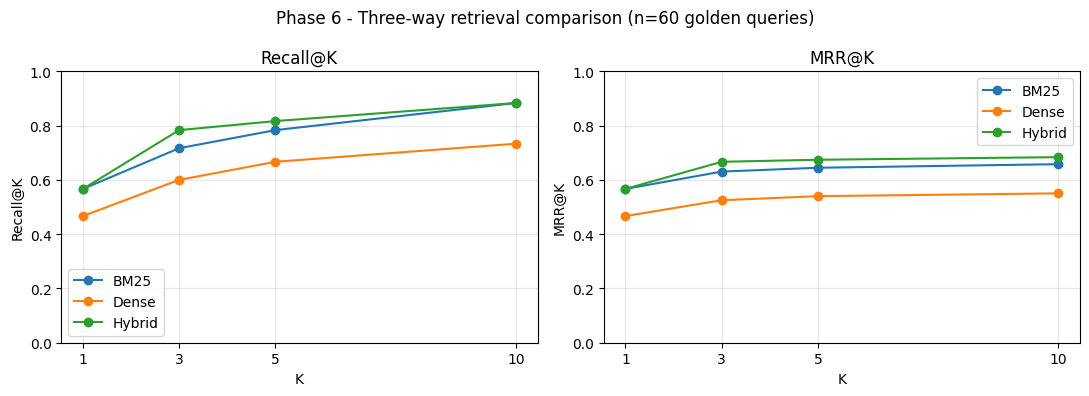

In [12]:
# Fig 12 — three-way metrics by K (Recall + MRR)
ks = list(K_VALUES)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, fam, title in [(axes[0], "recall", "Recall@K"), (axes[1], "mrr", "MRR@K")]:
    for name, tbl in (("BM25", pq_bm25), ("Dense", pq_dense), ("Hybrid", pq_hybrid)):
        ys = [tbl[f"{fam}@{k}"].mean() for k in ks]
        ax.plot(ks, ys, marker="o", label=name)
    ax.set_xlabel("K"); ax.set_ylabel(title); ax.set_title(title)
    ax.set_xticks(ks); ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend()
fig.suptitle("Phase 6 - Three-way retrieval comparison (n=60 golden queries)")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase06_three_way_metrics.png", dpi=150)
plt.show()

Figure 12 - phase06_three_way_metrics.png - "Three-way retrieval performance across cut-off K."
Recall@K (left) and MRR@K (right) for BM25, dense and hybrid at K=1/3/5/10 over the 60 golden queries. Hybrid (green) sits on or above BM25 (blue) at every K on both metrics, while dense (orange) trails throughout. The hybrid advantage is largest in the mid-range (Recall@3/@5, MRR@3/@5) and converges to BM25 at Recall@1 and Recall@10. This establishes that RRF fusion improves ranking quality without sacrificing BM25's recall frontier.

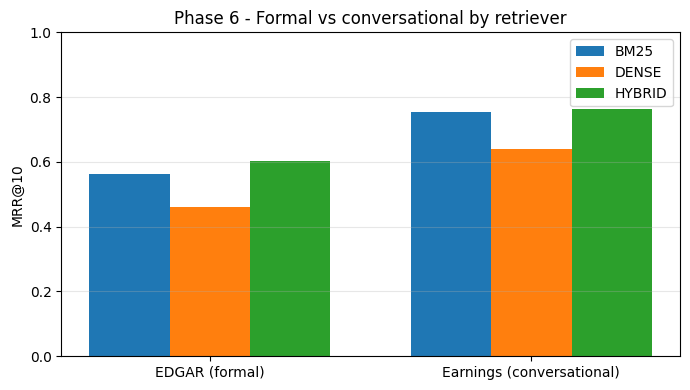

In [13]:
# Fig 13 — EDGAR vs earnings, MRR@10, three retrievers
fig, ax = plt.subplots(figsize=(7, 4))
sources = ["edgar", "earnings"]
x = np.arange(len(sources)); w = 0.25
for i, name in enumerate(("bm25","dense","hybrid")):
    vals = [by_source[name].loc[s, "mrr@10"] for s in sources]
    ax.bar(x + (i-1)*w, vals, w, label=name.upper())
ax.set_xticks(x); ax.set_xticklabels(["EDGAR (formal)","Earnings (conversational)"])
ax.set_ylabel("MRR@10"); ax.set_ylim(0,1); ax.grid(axis="y", alpha=.3)
ax.set_title("Phase 6 - Formal vs conversational by retriever"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "phase06_edgar_vs_earnings.png", dpi=150)
plt.show()

Figure 13 - phase06_edgar_vs_earnings.png - "Formal vs conversational retrieval by retriever (MRR@10)."
Mean MRR@10 on EDGAR (formal) and earnings (conversational) for each retriever. Hybrid (green) exceeds both BM25 and dense on each corpus. Critically, EDGAR rises under hybrid (0.56→0.60), whereas dense alone had depressed it (0.46) - fusion lifts the formal corpus that dense could not. The earnings-EDGAR gap narrows under hybrid because EDGAR improves, reversing the Phase-5 pattern where the gap moved only because earnings fell.

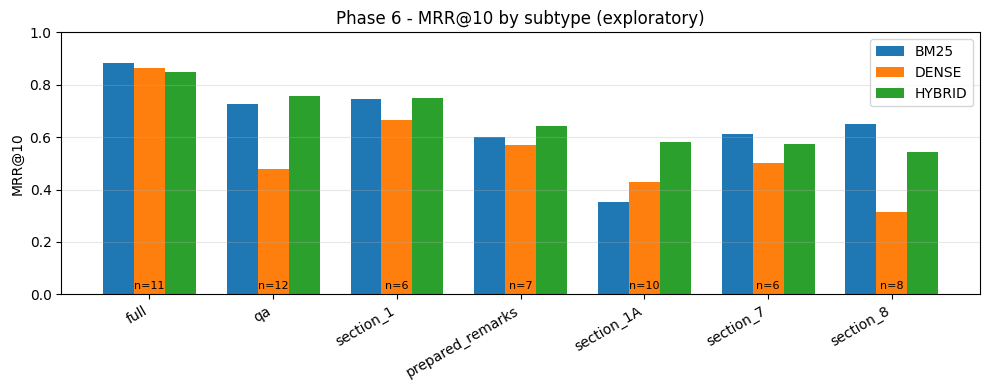

In [14]:
# Fig 14 — per-subtype MRR@10 (hybrid vs bm25 vs dense), section_1A annotated
order = subtype_mrr10.index.tolist()
x = np.arange(len(order)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(("bm25","dense","hybrid")):
    vals = [sub[name].loc[s, "mrr@10"] if s in sub[name].index else 0 for s in order]
    ax.bar(x + (i-1)*w, vals, w, label=name.upper())
for xi, s in enumerate(order):
    ax.annotate(f"n={int(subtype_mrr10.loc[s,'n'])}", (xi, 0.02), ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("MRR@10"); ax.set_ylim(0,1); ax.grid(axis="y", alpha=.3)
ax.set_title("Phase 6 - MRR@10 by subtype (exploratory)"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "phase06_mrr_by_subtype.png", dpi=150)
plt.show()

Figure 14 - phase06_mrr_by_subtype.png -"MRR@10 by document subtype (exploratory, n annotated)."
Per-subtype mean MRR@10 for the three retrievers, with query counts (n=6-12) annotated; values are indicative given the small per-cell samples. Hybrid wins clearly on the complementary mid-difficulty subtypes - section_1A (0.35→0.43→0.58), qa, section_1 and prepared_remarks - and dips marginally below BM25 on full, section_7 and section_8, where BM25 was already strong and dense weak. section_1A, the laggard of Phases 4–5, is the standout fusion gain.

C:\Users\anshu\AppData\Local\Temp\ipykernel_17912\236318263.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_ylabel("query count"); ax1.set_xticklabels(bs["bucket"], rotation=15)


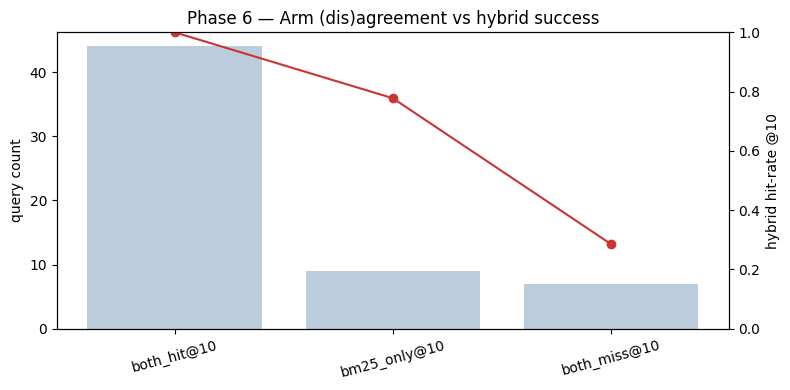

In [15]:
# Fig 15 — disagreement buckets: count + hybrid hit-rate@10
bs = bucket_summary.reset_index()
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(bs["bucket"], bs["n"], color="#bcd", label="query count")
ax1.set_ylabel("query count"); ax1.set_xticklabels(bs["bucket"], rotation=15)
ax2 = ax1.twinx()
ax2.plot(bs["bucket"], bs["hybrid_hit_rate_at10"], "o-", color="#c33", label="hybrid hit@10")
ax2.set_ylabel("hybrid hit-rate @10"); ax2.set_ylim(0,1)
ax1.set_title("Phase 6 — Arm (dis)agreement vs hybrid success")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase06_disagreement.png", dpi=150)
plt.show()

Figure 15 - phase06_disagreement.png - "Arm (dis)agreement versus hybrid success."
Bars show the number of queries in each hit@10 agreement bucket; the red line shows hybrid's hit-rate@10 within each bucket. Hybrid hits 100% of the 44 both-hit queries, holds 78% (7/9) of BM25-only wins, and rescues 29% (2/7) of queries both arms missed. There is no dense-only bucket - dense surfaced no top-10 chunk that BM25 missed - so the hybrid gain derives from rank-sharpening and consensus rescue, at a small cost on two BM25-only wins.

## 6. Write `phase_06_summary.json` from the real numbers
Machine-readable, written **only after** the run. Nothing here is hand-entered.

In [16]:
def m(tbl, metric): return round(float(tbl[metric].mean()), 4)

def overall_block(pq):
    return {c: m(pq, c) for c in MCOLS}

def source_block(name):
    t = by_source[name]
    return {src: {c: round(float(t.loc[src, c]), 4) for c in MCOLS} for src in t.index}

hybrid_beats_bm25 = bool(overall_tbl.loc["hybrid","mrr@10"] >= overall_tbl.loc["bm25","mrr@10"]
                         and overall_tbl.loc["hybrid","recall@10"] >= overall_tbl.loc["bm25","recall@10"])

summary = {
    "phase": 6,
    "retriever": "hybrid_rrf",
    "fusion": {"method": "reciprocal_rank_fusion", "k": RRF_K,
               "candidate_depth": CANDIDATE_DEPTH, "pool": "union", "tuned": False,
               "tie_break": "(-rrf_score, chunk_id)"},
    "composes": ["bm25_okapi", "dense_bge_small"],
    "chunks_indexed": int(len(chunks)),
    "golden_set": {"path": str(GOLDEN_PATH), "sha256": GOLDEN_SHA256,
                   "hash_assert": "PASS", "n_queries": int(len(golden))},
    "k_values": list(K_VALUES),
    "dense_backend": dense.backend,
    "metrics_overall": {
        "bm25": overall_block(pq_bm25),
        "dense": overall_block(pq_dense),
        "hybrid": overall_block(pq_hybrid),
    },
    "metrics_by_source": {
        "bm25": source_block("bm25"),
        "dense": source_block("dense"),
        "hybrid": source_block("hybrid"),
    },
    "metrics_by_subtype_mrr10": {
        s: {"bm25": round(float(sub["bm25"].loc[s,"mrr@10"]),4) if s in sub["bm25"].index else None,
            "dense": round(float(sub["dense"].loc[s,"mrr@10"]),4) if s in sub["dense"].index else None,
            "hybrid": round(float(sub["hybrid"].loc[s,"mrr@10"]),4),
            "n": int(subtype_mrr10.loc[s,"n"])}
        for s in subtype_mrr10.index
    },
    "section_1A_watch": {
        "bm25_mrr@10": round(float(sub["bm25"].loc["section_1A","mrr@10"]),4) if "section_1A" in sub["bm25"].index else None,
        "dense_mrr@10": round(float(sub["dense"].loc["section_1A","mrr@10"]),4) if "section_1A" in sub["dense"].index else None,
        "hybrid_mrr@10": round(float(sub["hybrid"].loc["section_1A","mrr@10"]),4) if "section_1A" in sub["hybrid"].index else None,
        "n": int(subtype_mrr10.loc["section_1A","n"]) if "section_1A" in subtype_mrr10.index else None,
    },
    "disagreement_buckets": {
        r["bucket"]: {"n": int(r["n"]), "hybrid_hit_rate_at10": round(float(r["hybrid_hit_rate_at10"]),4)}
        for _, r in bucket_summary.reset_index().iterrows()
    },
    "hypothesis_supported_overall": hybrid_beats_bm25,
    "hypothesis_note": ("Hybrid >= BM25 on both Recall@10 and MRR@10."
                        if hybrid_beats_bm25 else
                        "Hybrid did NOT match/beat BM25 overall; with dense the weaker arm, "
                        "unweighted RRF lands between the two. Complementary gains are localised "
                        "(see disagreement buckets + section_1A), not global. Citeable negative result."),
    "figures": [
        "reports/figures/phase06_three_way_metrics.png",
        "reports/figures/phase06_edgar_vs_earnings.png",
        "reports/figures/phase06_mrr_by_subtype.png",
        "reports/figures/phase06_disagreement.png",
    ],
}

out_path = NOTES_DIR / "phase_06_summary.json"
out_path.write_text(json.dumps(summary, indent=2))
disagree.to_csv(NOTES_DIR / "phase_06_disagreement.csv", index=False)
print("Wrote", out_path)
print(json.dumps(summary["metrics_overall"], indent=2))

Wrote d:\General IT\AI-ML-LJMU\final_thesis\code\notes\phase_06_summary.json
{
  "bm25": {
    "precision@1": 0.5667,
    "recall@1": 0.5667,
    "mrr@1": 0.5667,
    "precision@3": 0.2389,
    "recall@3": 0.7167,
    "mrr@3": 0.6306,
    "precision@5": 0.1567,
    "recall@5": 0.7833,
    "mrr@5": 0.6447,
    "precision@10": 0.0883,
    "recall@10": 0.8833,
    "mrr@10": 0.6579
  },
  "dense": {
    "precision@1": 0.4667,
    "recall@1": 0.4667,
    "mrr@1": 0.4667,
    "precision@3": 0.2,
    "recall@3": 0.6,
    "mrr@3": 0.525,
    "precision@5": 0.1333,
    "recall@5": 0.6667,
    "mrr@5": 0.54,
    "precision@10": 0.0733,
    "recall@10": 0.7333,
    "mrr@10": 0.5504
  },
  "hybrid": {
    "precision@1": 0.5667,
    "recall@1": 0.5667,
    "mrr@1": 0.5667,
    "precision@3": 0.2611,
    "recall@3": 0.7833,
    "mrr@3": 0.6667,
    "precision@5": 0.1633,
    "recall@5": 0.8167,
    "mrr@5": 0.6742,
    "precision@10": 0.0883,
    "recall@10": 0.8833,
    "mrr@10": 0.6838
  }
}


**phase_06_disagreement.csv** - is the per-query table the notebook saved alongside the summary - one row per golden query with bm25_rank, dense_rank, hybrid_rank, bucket, and hybrid_hit@10 (it's the big table printed in section 4). It's the raw evidence behind the bucket chart and the place you pull worked examples from for the thesis (q043, q034, q037, etc.). Keep it for your appendix.

## 7. Read-off (fill `phase_06_results.md` from the printed numbers)

Use the tables/figures above to complete `phase_06_results.md`:
1. **Overall** : does hybrid match/beat BM25 on Recall@10 and MRR@10? (`overall_tbl`, `deltas`)
2. **Formal vs conversational** : did the EDGAR–earnings gap move, and did **EDGAR rise**? (`gap_tbl`)
3. **section_1A** : did fusion hold/extend dense's edge? (`subtype_mrr10`, `section_1A_watch`)
4. **Disagreement** : does hybrid hold `bm25_only` wins and gain on `dense_only`? (`bucket_summary`)

Then state which pre-registered outcome held. Do **not** hand-edit `phase_06_summary.json`;
re-run this notebook to regenerate it.

Which outcome held (section 7): Outcome A. Concretely, the four read-off answers are :-

- (1) Overall: hybrid ties BM25 on Recall@10 (0.883) and beats it on MRR@10 (0.684 vs 0.658), plus every middle cut-off; 
- (2) Formal vs conversational: the gap narrowed and EDGAR rose (MRR@10 0.562→0.604), unlike Phase 5; 
- (3) section_1A: fusion extended the edge to 0.583, beating both arms; 
- (4) Disagreement: held 7/9 BM25-only wins, rescued 2/7 both-miss, with no dense-only bucket to gain on.